# Compare intervention size and direction

Change selected outputs of a small, untrained network and measure the consequences. Compare one unit, several units, and a whole layer; then compare zeroing with adding a value.

**Requirements:** CPU; no downloads.

`Selection` chooses the target and `Perturbation` defines the change. This is the explicit interface behind the `Ablate` tool in notebook 18. More changed units need not cause a larger output change; measure the effect rather than assuming its direction.


In [1]:
import warnings
warnings.filterwarnings('ignore', message='.*__slots__.*', category=FutureWarning)
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from brainscore_core.model_interface import BrainScoreModel, StateChange, Selection, Perturbation
from brainscore.perturbation import build_pytorch_ablation_fn
torch.manual_seed(0)                    # same weights every run

# A small stack of layers: 64 numbers in, down through 32 and 16, out as 4.
# nn.Sequential numbers its children by position, so '3' below means the 4th entry --
# the Linear layer with 16 units, which is the target of the interventions below.
net = nn.Sequential(nn.Flatten(), nn.Linear(64, 32), nn.ReLU(),
                    nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 4)).eval()

# Wrap it so state-change instructions can be issued and subsequently undone.
subject = BrainScoreModel('interv', None, {}, {}, None, state_change_fn=build_pytorch_ablation_fn(net))

# One fixed input, and what the untouched network says about it.
x = torch.randn(1, 64)
with torch.no_grad():
    base = net(x).clone()

def apply(target, pert):
    '''Interfere with some units, see how the output moves, then put it back.

    Returns two numbers:
      - magnitude: how far the output moved overall (always positive)
      - signed shift: which way it moved on average (positive = up, negative = down)
    '''
    a = subject.process(StateChange(kind='ablation', target=target, perturbation=pert))
    with torch.no_grad():
        out = net(x).clone()
    subject.process(StateChange(kind='reset', handle_id=a.handle_id))   # undo just this change
    return float((out - base).norm()), float((out - base).mean())


## 1. Scope: same operation, more units

Silencing of 1 unit of L3, then 8, then all 16 — same layer, same kind, growing count.


In [2]:
# First axis: SCOPE. Same operation (silence the units), applied to more and more of them.
scope = [('1 unit of L3', Selection('3', [5])),
         ('8 units of L3', Selection('3', list(range(8)))),
         ('all 16 of L3', Selection('3'))]      # no index list = the whole layer
# Measure how output change varies with the selection.
for name, target in scope:
    eff, _ = apply(target, Perturbation(kind='zero'))
    print(f'{name:24s} effect = {eff:.3f}')


1 unit of L3             effect = 0.047
8 units of L3            effect = 0.202
all 16 of L3             effect = 0.257


## 2. Compare zeroing and adding activity

Zero unit 5, then add 8 to its output in a separate run. Measure each signed shift relative to the unchanged model. Its sign depends on the model and input.


In [3]:
# Second axis: DIRECTION. Same single unit, but silenced versus over-driven.
# Measure the direction; it depends on the network and input.
_, silenced_shift = apply(Selection('3', [5]), Perturbation(kind='zero'))
_, driven_shift = apply(Selection('3', [5]), Perturbation(kind='drive', amount=8.0))
print(f'silence unit 5:      signed shift = {silenced_shift:+.3f}')
print(f'add to unit 5:   signed shift = {driven_shift:+.3f}')
print('opposite directions:', (silenced_shift < 0) != (driven_shift < 0))


silence unit 5:      signed shift = -0.020
add to unit 5:   signed shift = +0.846
opposite directions: True


## 3. The two comparisons


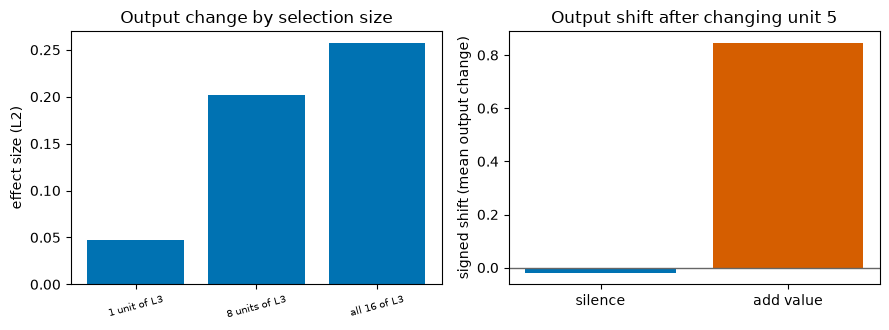

In [4]:
# Re-run the scope sweep, keeping just the L2 effect size for the bar chart.
effs = [apply(t, Perturbation(kind='zero'))[0] for _, t in scope]
# Left: effect vs selection size. Right: signed shift, silencing vs adding a value.
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
ax[0].bar([n for n, _ in scope], effs, color='#0072B2')
ax[0].set_ylabel('effect size (L2)')
ax[0].set_title('Output change by selection size')
ax[0].tick_params(axis='x', rotation=15, labelsize=7.5)
ax[1].bar(['silence', 'add value'], [silenced_shift, driven_shift], color=['#0072B2', '#D55E00'])
ax[1].axhline(0, c='0.4', lw=1)
ax[1].set_ylabel('signed shift (mean output change)')
ax[1].set_title('Output shift after changing unit 5')
fig.tight_layout()
plt.show()


Selection size and intervention type change the experiment. The measured direction and magnitude need not generalize to another input or model. Each change is removed before the next; the final cell checks restoration.


## 4. Exact restoration


In [5]:
# Every change above was undone as it went. Confirm the network really is untouched --
# exactly equal, not merely close.
with torch.no_grad():
    restored = net(x).clone()
print('output identical to baseline after all resets:', bool(torch.equal(restored, base)))


output identical to baseline after all resets: True


[Notebook guide](README.md) · [Shared vocabulary](../docs/conventions.md)
